## 세종특별자치시 주차장 정보

### 라이브러리 Import

In [1]:
import pandas as pd
import time
import requests
import os
from dotenv import load_dotenv # API 키 관리를 위한 라이브러리
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['font.family'] = 'AppleGothic', 'Malgun Gothic', 'NanumGothic', 'Sans-serif'
matplotlib.rcParams['axes.unicode_minus'] = False

### 데이터 프레임 생성

In [2]:
data_path = "../data/raw/세종특별자치시_주차장정보.csv"

df = pd.read_csv(data_path, encoding="CP949")
print(df.head())

    적재_연월      주차장 명칭 주차장 구분자 정보 주차장 유형 구분자 정보             주차장 위치 도로명주소정보  \
0  202604        죽림리3         공영            노외        세종특별자치시 조치원읍 죽림본로 9   
1  202604        죽림리4         공영            노외        세종특별자치시 조치원읍 죽림로 37   
2  202604         남리1         공영            노외  세종특별자치시 조치원읍 조치원4길 144-15   
3  202604         상리1         공영            노외       세종특별자치시 조치원읍 조치원로 54   
4  202604  세종전통시장주차타워         공영            노외     세종특별자치시 조치원읍 새내8길 17-1   

  주차장 위치 지번주소정보  주차장 주차 구획수 주차장 부제 시행 구분자 정보    주차장 운영요일 주차장 평일 운영시작시각  ...  \
0             -          29              미시행  평일+토요일+공휴일          7:00  ...   
1             -          22              미시행  평일+토요일+공휴일          7:00  ...   
2             -          45              미시행  평일+토요일+공휴일          7:00  ...   
3             -         131              미시행  평일+토요일+공휴일          7:00  ...   
4             -         149              미시행  평일+토요일+공휴일          8:00  ...   

  주차장 추가 단위요금 주차장 1일 주차권 요금 적용시간 주차장 1일 주차권 요금 주차장 월 정기권 요금 주차

### 필요한 컬럼 추출

In [3]:
cleaned_df = df[["주차장 명칭", "주차장 위치 도로명주소정보", "주차장 주차 구획수"]]
cleaned_df

,주차장 명칭,주차장 위치 도로명주소정보,주차장 주차 구획수
0,죽림리3,세종특별자치시 조치원읍 죽림본로 9,29
1,죽림리4,세종특별자치시 조치원읍 죽림로 37,22
2,남리1,세종특별자치시 조치원읍 조치원4길 144-15,45
3,상리1,세종특별자치시 조치원읍 조치원로 54,131
4,세종전통시장주차타워,세종특별자치시 조치원읍 새내8길 17-1,149
5,이벤트광장,세종특별자치시 조치원읍 장안길 14,25
6,신흥리2,세종특별자치시 조치원읍 신흥샛터길 37,28
7,죽림리1,세종특별자치시 조치원읍 도장말길 52,15
8,죽림리2,세종특별자치시 조치원읍 새동네뒷골길 7-1,9
9,교리1,세종특별자치시 조치원읍 문화로 17,34


### API를 통한 지역 정보 매핑
API 정보: https://business.juso.go.kr/jst/jstRoadNmAddrApiSearch

In [4]:
load_dotenv()
juso_api_key = os.getenv("JUSO_API_KEY")

def get_emd_name(roadAddr, api_key):
    url = "https://business.juso.go.kr/addrlink/addrLinkApi.do"

    params = {
        "currentPage": 1,
        "countPerPage": 1,
        "keyword": roadAddr,
        "confmKey": juso_api_key,
        "resultType": "json"
    }

    try:
        response = requests.get(url, params=params)

        if response.status_code == 200:
            data = response.json()
            juso_list = data.get("results", {}).get("juso", [])

        return juso_list[0].get("emdNm", "정보 없음") if juso_list else "정보 없음"
    
    except Exception as e:
        return f"오류({str(e)})"
    

cleaned_df['지역'] = cleaned_df['주차장 위치 도로명주소정보'].apply(lambda x: get_emd_name(x, juso_api_key))
cleaned_df.head()

,주차장 명칭,주차장 위치 도로명주소정보,주차장 주차 구획수,지역
0,죽림리3,세종특별자치시 조치원읍 죽림본로 9,29,조치원읍
1,죽림리4,세종특별자치시 조치원읍 죽림로 37,22,조치원읍
2,남리1,세종특별자치시 조치원읍 조치원4길 144-15,45,조치원읍
3,상리1,세종특별자치시 조치원읍 조치원로 54,131,조치원읍
4,세종전통시장주차타워,세종특별자치시 조치원읍 새내8길 17-1,149,조치원읍


### API로 지역이 매핑되지 않는 경우 직접 매핑

In [5]:
missing_values = cleaned_df[cleaned_df['지역'] == "정보 없음"]
print(missing_values)

cleaned_df.loc[cleaned_df['주차장 명칭'] == "신흥리2", '지역'] = "조치원읍"
cleaned_df.loc[cleaned_df['주차장 명칭'] == "용포로공영주차장", '지역'] = "금남면" 
cleaned_df

      주차장 명칭         주차장 위치 도로명주소정보  주차장 주차 구획수     지역
6       신흥리2  세종특별자치시 조치원읍 신흥샛터길 37          28  정보 없음
47  용포로공영주차장                      -          55  정보 없음


,주차장 명칭,주차장 위치 도로명주소정보,주차장 주차 구획수,지역
0,죽림리3,세종특별자치시 조치원읍 죽림본로 9,29,조치원읍
1,죽림리4,세종특별자치시 조치원읍 죽림로 37,22,조치원읍
2,남리1,세종특별자치시 조치원읍 조치원4길 144-15,45,조치원읍
3,상리1,세종특별자치시 조치원읍 조치원로 54,131,조치원읍
4,세종전통시장주차타워,세종특별자치시 조치원읍 새내8길 17-1,149,조치원읍
5,이벤트광장,세종특별자치시 조치원읍 장안길 14,25,조치원읍
6,신흥리2,세종특별자치시 조치원읍 신흥샛터길 37,28,조치원읍
7,죽림리1,세종특별자치시 조치원읍 도장말길 52,15,조치원읍
8,죽림리2,세종특별자치시 조치원읍 새동네뒷골길 7-1,9,조치원읍
9,교리1,세종특별자치시 조치원읍 문화로 17,34,조치원읍


### 주차장 데이터 정리

In [6]:
# 세종시 지역 추출
region = pd.read_csv("../data/processed/illegal_summary.csv")["지역"]
region.head()

# 지역별 주차 구획수 합계 + 지역별 주차장 수
summary = cleaned_df.groupby('지역').agg({'주차장 명칭': 'count', '주차장 주차 구획수': 'sum'}).rename(columns={'주차장 명칭': '주차장수', '주차장 주차 구획수': '주차구획수'})

# region에 없는 지역을 주차장 수 0, 주차 구획수 0으로 추가
for r in region:
    if r not in summary.index:
        summary.loc[r] = [0, 0]
summary = summary.sort_index()
sorted_summary = summary.sort_values(by='주차구획수', ascending=False)
print(sorted_summary)
sorted_summary.to_csv("../data/processed/parking_summary.csv")

      주차장수  주차구획수
지역               
조치원읍    38   1299
나성동      4    882
보람동      4    238
아름동      1    236
종촌동      1    160
금남면      2     96
부강면      5     72
전의면      1     65
소담동      1     51
한솔동      1     33
도담동      1     13
연동면      1     10
다정동      0      0
세종동      0      0
새롬동      0      0
산울동      0      0
반곡동      0      0
대평동      0      0
가람동      0      0
고운동      0      0
소정면      0      0
장군면      0      0
연서면      0      0
연기면      0      0
어진동      0      0
전동면      0      0
집현동      0      0
한별동      0      0
해밀동      0      0


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

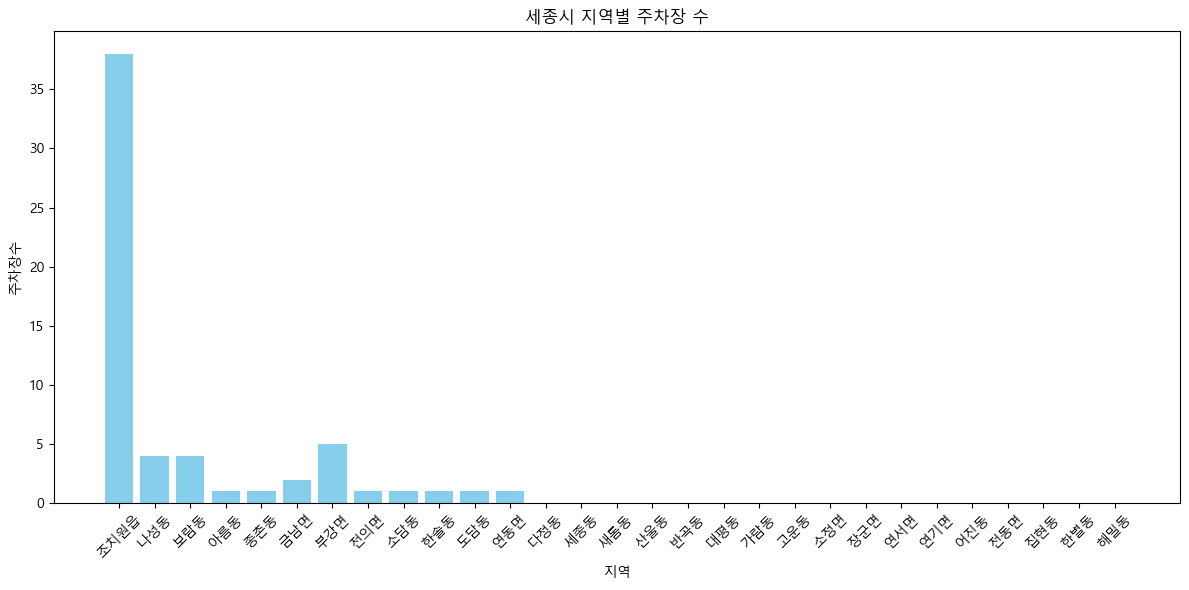

In [7]:
# sorted_summary 시각화 
plt.figure(figsize=(12, 6))
plt.bar(sorted_summary.index, sorted_summary['주차장수'], color='skyblue')
plt.xlabel('지역')
plt.ylabel('주차장수')
plt.title('세종시 지역별 주차장 수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

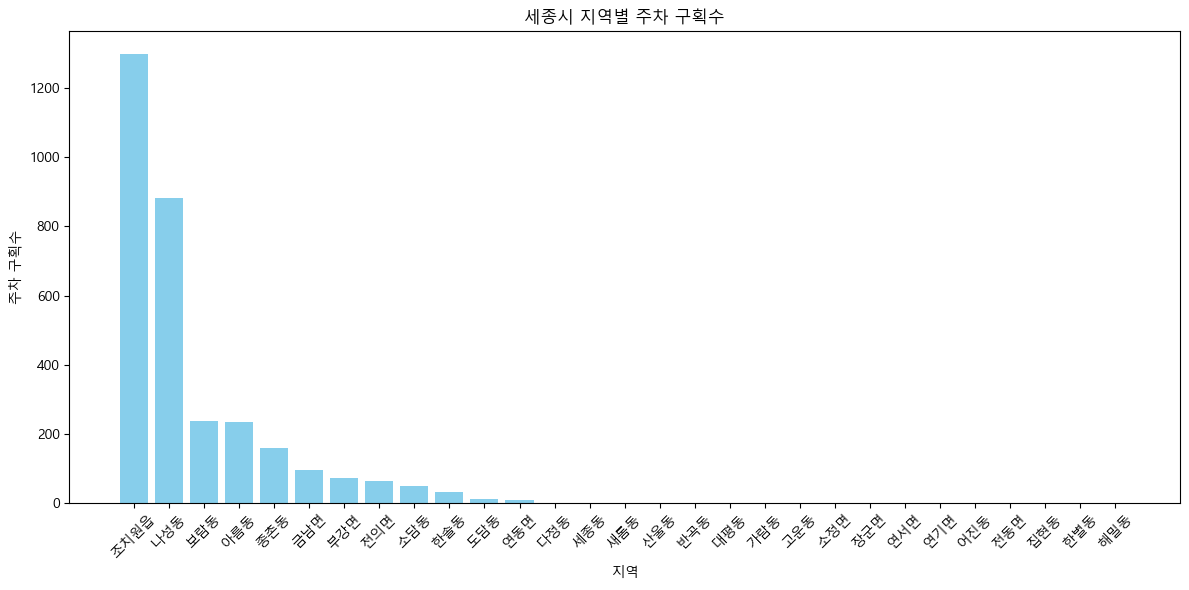

In [8]:
# sorted_summary 시각화 
plt.figure(figsize=(12, 6))
plt.bar(sorted_summary.index, sorted_summary['주차구획수'], color='skyblue')
plt.xlabel('지역')
plt.ylabel('주차 구획수')
plt.title('세종시 지역별 주차 구획수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [9]:
df

,적재_연월,주차장 명칭,주차장 구분자 정보,주차장 유형 구분자 정보,주차장 위치 도로명주소정보,주차장 위치 지번주소정보,주차장 주차 구획수,주차장 부제 시행 구분자 정보,주차장 운영요일,주차장 평일 운영시작시각,...,주차장 추가 단위요금,주차장 1일 주차권 요금 적용시간,주차장 1일 주차권 요금,주차장 월 정기권 요금,주차장 결제 방법 정보,주차장 관리기관명,주차장 관리기관 전화번호,주차장 위치 위도 좌표정보,주차장 위치 경도 좌표정보,주차장 데이터 기준일자
0,202604,죽림리3,공영,노외,세종특별자치시 조치원읍 죽림본로 9,-,29,미시행,평일+토요일+공휴일,7:00,...,0,0,0,0,-,세종특별자치시청,044-300-7923,36.591358,127.297680,2023-11-24
1,202604,죽림리4,공영,노외,세종특별자치시 조치원읍 죽림로 37,-,22,미시행,평일+토요일+공휴일,7:00,...,0,0,0,0,-,세종특별자치시청,044-300-7923,36.592130,127.295639,2023-11-24
2,202604,남리1,공영,노외,세종특별자치시 조치원읍 조치원4길 144-15,-,45,미시행,평일+토요일+공휴일,7:00,...,0,0,0,0,-,세종특별자치시청,044-300-7923,36.594587,127.299663,2023-11-24
3,202604,상리1,공영,노외,세종특별자치시 조치원읍 조치원로 54,-,131,미시행,평일+토요일+공휴일,7:00,...,0,0,0,0,-,세종특별자치시청,044-300-7923,36.601868,127.302626,2023-11-24
4,202604,세종전통시장주차타워,공영,노외,세종특별자치시 조치원읍 새내8길 17-1,-,149,미시행,평일+토요일+공휴일,8:00,...,400,0,8000,0,카드,세종특별자치시청,044-300-7923,36.599828,127.299317,2023-11-24
5,202604,이벤트광장,공영,노외,세종특별자치시 조치원읍 장안길 14,-,25,미시행,평일+토요일+공휴일,8:00,...,400,0,8000,0,카드,세종특별자치시청,044-300-7923,36.599861,127.300029,2023-11-24
6,202604,신흥리2,공영,노외,세종특별자치시 조치원읍 신흥샛터길 37,-,28,미시행,평일+토요일+공휴일,7:00,...,0,0,0,0,-,세종특별자치시청,044-300-7923,36.597180,127.294688,2023-11-24
7,202604,죽림리1,공영,노상,세종특별자치시 조치원읍 도장말길 52,-,15,미시행,평일+토요일+공휴일,7:00,...,0,0,0,0,-,세종특별자치시청,044-300-7923,36.591621,127.297478,2023-11-24
8,202604,죽림리2,공영,노외,세종특별자치시 조치원읍 새동네뒷골길 7-1,-,9,미시행,평일+토요일+공휴일,7:00,...,0,0,0,0,-,세종특별자치시청,044-300-7923,36.589811,127.292240,2023-11-24
9,202604,교리1,공영,노상,세종특별자치시 조치원읍 문화로 17,-,34,미시행,평일+토요일+공휴일,7:00,...,0,0,0,0,-,세종특별자치시청,044-300-7923,36.603316,127.300594,2023-11-24


In [10]:
parking_locations = df[['주차장 명칭','주차장 주차 구획수','주차장 위치 위도 좌표정보', '주차장 위치 경도 좌표정보']]
parking_locations.columns = ['주차장 명칭', '주차구획수', '위도', '경도']
parking_locations
parking_locations.to_csv("../data/processed/parking_lot_locations.csv")